## Imports

In [1]:
import sys
import os
import torch
import torch.utils.data as data
import torch.nn as nn

import neuro_fuzzy_toolbox as nft

## Data

In [2]:
x_train = 2 * torch.rand(200, 2) - 1
x_train

tensor([[ 0.2492,  0.2834],
        [-0.5286, -0.0456],
        [ 0.3187, -0.9318],
        [ 0.2466, -0.1078],
        [ 0.4211,  0.0628],
        [ 0.8042, -0.5844],
        [ 0.1234,  0.6126],
        [ 0.5589, -0.3660],
        [ 0.7597,  0.4540],
        [-0.4623,  0.4462],
        [-0.7245, -0.0272],
        [-0.3466, -0.5926],
        [-0.8567, -0.1791],
        [-0.1880, -0.5134],
        [-0.6232,  0.4254],
        [ 0.9058,  0.9884],
        [-0.1036, -0.7115],
        [-0.7031,  0.2366],
        [-0.4154, -0.1632],
        [-0.2253, -0.3196],
        [ 0.0848, -0.2912],
        [-0.5048,  0.4773],
        [ 0.3912, -0.2259],
        [-0.0066,  0.5253],
        [-0.3025, -0.0203],
        [ 0.7708, -0.2478],
        [ 0.0312, -0.4644],
        [ 0.9699,  0.1329],
        [-0.3015,  0.5952],
        [-0.9795, -0.4023],
        [-0.9387, -0.5726],
        [-0.0694,  0.9488],
        [-0.0136,  0.5124],
        [-0.8564, -0.5487],
        [ 0.5173,  0.4626],
        [-0.5235, -0

In [3]:
y_train = torch.rand(200)
y_train

tensor([0.3076, 0.9646, 0.2654, 0.4083, 0.6726, 0.4721, 0.6080, 0.6302, 0.6056,
        0.0454, 0.4217, 0.3134, 0.2846, 0.0434, 0.0366, 0.0721, 0.6521, 0.2886,
        0.5657, 0.6513, 0.0496, 0.2870, 0.0459, 0.2287, 0.4984, 0.0330, 0.0423,
        0.0648, 0.3755, 0.6137, 0.8799, 0.4530, 0.2452, 0.8184, 0.1280, 0.7818,
        0.7659, 0.6961, 0.0617, 0.2451, 0.1120, 0.9616, 0.0093, 0.6739, 0.0027,
        0.2580, 0.2159, 0.3288, 0.9197, 0.2006, 0.5607, 0.0211, 0.3816, 0.7119,
        0.0291, 0.5335, 0.7798, 0.0798, 0.3672, 0.0785, 0.3805, 0.4066, 0.7614,
        0.7471, 0.3106, 0.0694, 0.1477, 0.7659, 0.1838, 0.4575, 0.0568, 0.4088,
        0.5383, 0.1422, 0.4058, 0.8502, 0.6725, 0.6615, 0.3260, 0.3336, 0.8492,
        0.8247, 0.3175, 0.5495, 0.4762, 0.2557, 0.5633, 0.4615, 0.3948, 0.8945,
        0.1988, 0.3338, 0.7286, 0.3555, 0.1710, 0.1013, 0.7456, 0.6106, 0.0177,
        0.2529, 0.5236, 0.8291, 0.8355, 0.0388, 0.4128, 0.9147, 0.8549, 0.5290,
        0.0698, 0.5481, 0.8635, 0.2306, 

## Model

In [4]:
model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=8, # 8 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.GeneralizedBell_MF(), # Función de membresía gaussiana
    output_type='default', # Tipo de salida: default
)

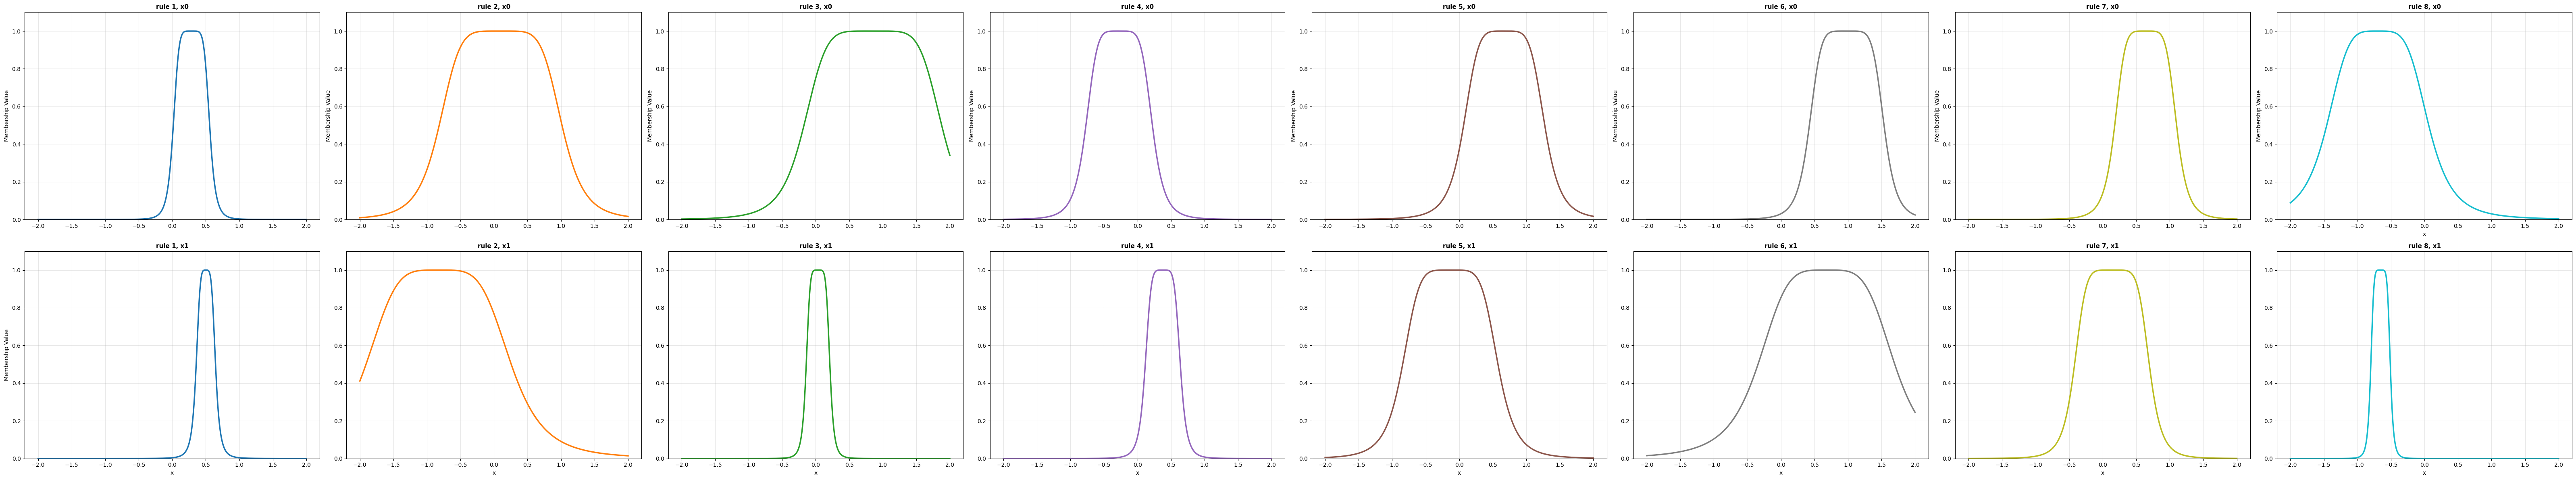

In [5]:
model.plot_premises()

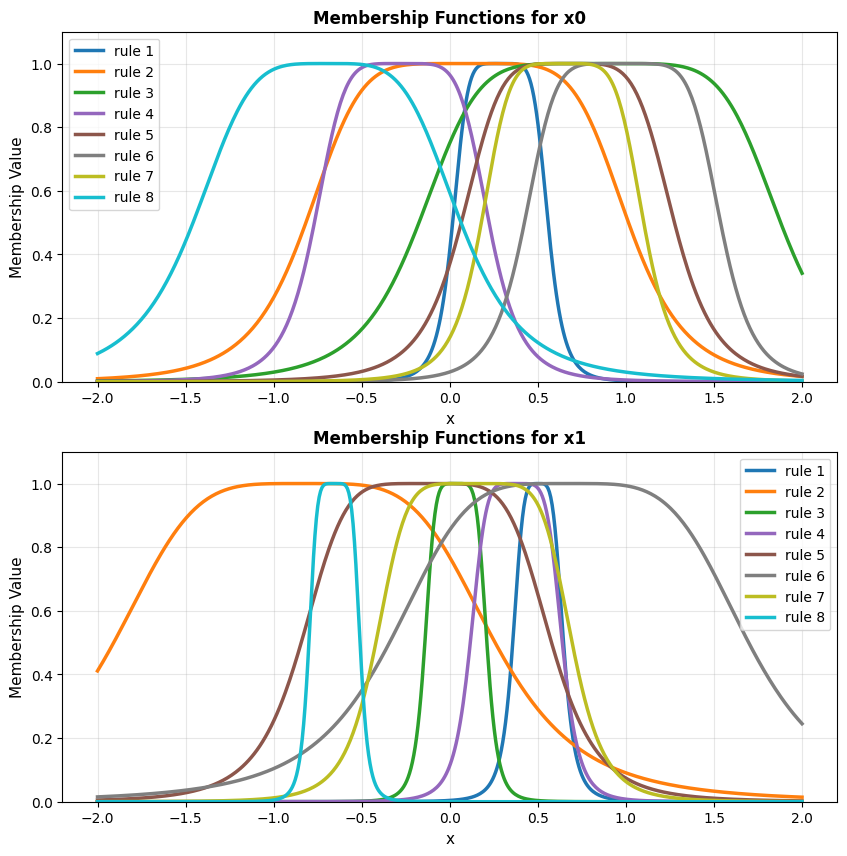

In [6]:
model.plot_premises(group_by_dim=True)

In [7]:
model.get_premises_structure()

x0                            x1                    
               a         b         c         a         b         c
rule 1  0.271039  3.034155  0.287147  0.144155  2.205971  0.501727
rule 2  0.915798  2.803364  0.098967  1.082744  2.207187 -0.825397
rule 3  1.026692  2.946334  0.851807  0.175985  2.877685  0.034717
rule 4  0.495579  2.765171 -0.273076    0.2612  2.783226  0.377702
rule 5  0.605038  2.576934  0.670515  0.710577  2.708276 -0.132784
rule 6  0.556809  3.050039   0.98062   1.01968  2.162477  0.677389
rule 7  0.461018  2.776725  0.640296  0.557074  3.080677  0.137537
rule 8  0.760702  2.165563 -0.696888  0.145167  3.029904 -0.654647

In [8]:
model.get_premises()

tensor([[[ 0.2710,  3.0342,  0.2871],
         [ 0.9158,  2.8034,  0.0990],
         [ 1.0267,  2.9463,  0.8518],
         [ 0.4956,  2.7652, -0.2731],
         [ 0.6050,  2.5769,  0.6705],
         [ 0.5568,  3.0500,  0.9806],
         [ 0.4610,  2.7767,  0.6403],
         [ 0.7607,  2.1656, -0.6969]],

        [[ 0.1442,  2.2060,  0.5017],
         [ 1.0827,  2.2072, -0.8254],
         [ 0.1760,  2.8777,  0.0347],
         [ 0.2612,  2.7832,  0.3777],
         [ 0.7106,  2.7083, -0.1328],
         [ 1.0197,  2.1625,  0.6774],
         [ 0.5571,  3.0807,  0.1375],
         [ 0.1452,  3.0299, -0.6546]]])

In [9]:
model.get_consequents_structure()[0]

,x0,x1,
,c0,c1,c2
rule 1,0.080596,0.108606,-0.577108
rule 2,0.138052,-0.865162,0.365198
rule 3,0.146151,0.143233,0.744469
rule 4,0.642081,0.274717,0.676761
rule 5,-0.335628,0.736038,0.256845
rule 6,0.997304,-0.899369,0.603140
rule 7,0.171153,-0.605300,-0.995007
rule 8,0.578274,0.004273,0.061046


In [10]:
model.init_consequents(x_train, y_train)

In [11]:
model.get_consequents_structure()[0]

,x0,x1,
,c0,c1,c2
rule 1,-2.213577,4.901662,-1.945322
rule 2,-0.079596,0.036174,0.356876
rule 3,-1.141224,1.003815,0.902159
rule 4,-0.102043,0.711272,0.017282
rule 5,0.138940,-0.313853,1.144341
rule 6,-0.481440,0.773742,-0.695250
rule 7,2.620912,1.699722,-1.101108
rule 8,-0.271290,0.722929,0.997285


In [12]:
model.get_rules_structure()

premises                                                    \
              x0                            x1                       
               a         b         c         a         b         c   
rule 1  0.271039  3.034155  0.287147  0.144155  2.205971  0.501727   
rule 2  0.915798  2.803364  0.098967  1.082744  2.207187 -0.825397   
rule 3  1.026692  2.946334  0.851807  0.175985  2.877685  0.034717   
rule 4  0.495579  2.765171 -0.273076    0.2612  2.783226  0.377702   
rule 5  0.605038  2.576934  0.670515  0.710577  2.708276 -0.132784   
rule 6  0.556809  3.050039   0.98062   1.01968  2.162477  0.677389   
rule 7  0.461018  2.776725  0.640296  0.557074  3.080677  0.137537   
rule 8  0.760702  2.165563 -0.696888  0.145167  3.029904 -0.654647   

       output 1 consequents                      
                         x0        x1            
                         c0        c1        c2  
rule 1            -2.213577  4.901662 -1.945322  
rule 2            -0.079596  0.036174  0.356876  
rule 3            -1.141224  1.003815  0.902159  
rule 4            -0.102043  0.711272  0.017282  
rule 5             0.138940 -0.313853  1.144341  
rule 6            -0.481440  0.773742 -0.695250  
rule 7             2.620912  1.699722 -1.101108  
rule 8            -0.271290  0.722929  0.997285

In [13]:
model(x_train[:10])

tensor([0.3597, 0.5371, 0.5107, 0.3491, 0.3836, 0.5051, 0.5807, 0.3148, 0.5830,
        0.3909], grad_fn=<SqueezeBackward1>)

In [14]:
with torch.no_grad():
    output = model(x_train[:10])

print(output)

tensor([0.3597, 0.5371, 0.5107, 0.3491, 0.3836, 0.5051, 0.5807, 0.3148, 0.5830,
        0.3909])


In [15]:
model.predict(x_train[:10])

tensor([0.3597, 0.5371, 0.5107, 0.3491, 0.3836, 0.5051, 0.5807, 0.3148, 0.5830,
        0.3909])

## Binary output

In [16]:
x_train = 2 * torch.rand(200, 3) - 1

In [17]:
y_train = torch.randint(0, 2, (200,))
y_train[:10]

tensor([0, 0, 1, 0, 1, 0, 1, 0, 0, 0])

In [18]:
bin_model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=10, # 10 funciones de membresía
    outputs=1, # 1 salida
    membership_function=nft.Gaussian_MF(), # Función de membresía gaussiana
    output_type='sigmoid', # Tipo de salida: capa sigmoide
)

In [19]:
bin_model.predict(x_train[:10])

tensor([0, 1, 1, 1, 0, 0, 0, 0, 1, 1])

In [20]:
bin_model(x_train[:10])

tensor([0.3723, 0.5889, 0.6424, 0.5287, 0.3988, 0.4826, 0.4749, 0.4527, 0.5323,
        0.5362], grad_fn=<SigmoidBackward0>)

## Multiclass output

In [21]:
x_train = 2 * torch.rand(200, 3) - 1

In [22]:
y_train = torch.randint(0, 4, (200,))
y_train[:10]

tensor([2, 0, 3, 3, 2, 3, 2, 3, 1, 3])

In [23]:
mul_class_model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 3 features
    num_mfs=15, # 3 funciones de membresía
    outputs=4, # 4 clases
    membership_function=nft.Gaussian_MF(), # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: capa softmax
)

In [24]:
mul_class_model.predict(x_train[:10])

tensor([2, 3, 2, 3, 2, 2, 3, 3, 2, 0])

In [25]:
mul_class_model(x_train[:10])

tensor([[ 0.0414, -0.6283,  0.1432, -0.1797],
        [-0.2260, -0.3330, -0.1557,  0.4017],
        [-0.9989, -0.1264,  0.6881,  0.5995],
        [-0.1944, -0.3132, -0.1052,  0.3383],
        [-0.0178, -0.3674,  0.1865,  0.1504],
        [-0.2117, -0.4021,  0.0543, -0.0473],
        [ 0.0731, -0.1744,  0.1177,  0.1487],
        [-0.5323, -0.0488,  0.3105,  0.3747],
        [-0.2393, -0.2122,  0.5581,  0.4918],
        [ 0.2456, -0.6075, -0.1246, -0.1883]], grad_fn=<SqueezeBackward1>)

In [26]:
mul_class_model(x_train[:10], return_probs=True)

tensor([[0.2924, 0.1496, 0.3237, 0.2343],
        [0.2064, 0.1855, 0.2215, 0.3867],
        [0.0728, 0.1741, 0.3932, 0.3599],
        [0.2135, 0.1895, 0.2334, 0.3636],
        [0.2430, 0.1713, 0.2981, 0.2875],
        [0.2320, 0.1918, 0.3027, 0.2735],
        [0.2561, 0.1999, 0.2678, 0.2762],
        [0.1347, 0.2185, 0.3130, 0.3337],
        [0.1581, 0.1625, 0.3510, 0.3285],
        [0.3617, 0.1541, 0.2498, 0.2344]], grad_fn=<SoftmaxBackward0>)

In [27]:
print(mul_class_model.get_rules_structure().to_string())

         premises                                                   output 1 consequents                               output 2 consequents                               output 3 consequents                               output 4 consequents                              
               x0                  x1                  x2                             x0        x1        x2                             x0        x1        x2                             x0        x1        x2                             x0        x1        x2          
               mu     sigma        mu     sigma        mu     sigma                   c0        c1        c2        c3                   c0        c1        c2        c3                   c0        c1        c2        c3                   c0        c1        c2        c3
rule 1  -0.305212  0.180684 -0.672191  0.700392  0.444825  0.475378            -0.746819  0.608824  0.694722 -0.756094             0.026485  0.862561 -0.319715  0.429924             0.

## Multiple outputs

In [28]:
x_train = 2 * torch.rand(200, 2) - 1

In [29]:
model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=9, # 9 funciones de membresía
    outputs=2, # 2 salidas
    membership_function=nft.Gaussian_MF(), # Función de membresía gaussiana
    output_type='default', # Tipo de salida: default
)

In [30]:
model.get_consequents_structure()

[              x0        x1          
               c0        c1        c2
 rule 1  0.863998 -0.849320 -0.605432
 rule 2 -0.649713 -0.341145  0.320564
 rule 3  0.969398  0.401906 -0.407749
 rule 4  0.881927  0.154284  0.008825
 rule 5 -0.103516 -0.359598 -0.248640
 rule 6  0.553004 -0.840338 -0.683082
 rule 7 -0.617229 -0.899412 -0.115674
 rule 8 -0.778746  0.877241  0.242130
 rule 9 -0.261775  0.626985  0.097524,
               x0        x1          
               c0        c1        c2
 rule 1  0.978030  0.690137 -0.847051
 rule 2  0.034442 -0.300502 -0.995466
 rule 3  0.791741 -0.190410 -0.915736
 rule 4  0.139739  0.889453  0.707198
 rule 5 -0.717879 -0.015024  0.322546
 rule 6  0.071745  0.572337 -0.279102
 rule 7 -0.312259 -0.558022  0.649734
 rule 8 -0.709467  0.072396 -0.034950
 rule 9 -0.343572 -0.815414 -0.504286]

In [31]:
model(x_train[:10])

tensor([[-0.2001, -0.2990],
        [-0.1132, -0.5128],
        [-0.3056, -0.2322],
        [-0.1806, -0.2874],
        [-0.3059, -0.0181],
        [ 0.0026, -0.0985],
        [-0.3686,  0.0697],
        [-0.1359, -0.4607],
        [ 0.0237, -0.0076],
        [-0.1631, -0.3995]], grad_fn=<SqueezeBackward1>)

## Multiclass problem

In [32]:
x_train = 2 * torch.rand(200, 2) - 1 # ejemplo de datos de entrenamiento con 2 features

model = nft.rule_reduced_ANFIS(
    input_size=x_train.shape[1], # 2 features
    num_mfs=6, # 6 funciones de membresía
    outputs=3, # 3 salidas
    membership_function=nft.Gaussian_MF(), # Función de membresía gaussiana
    output_type='softmax', # Tipo de salida: capa softmax
)

In [33]:
model(x_train[:10])

tensor([[ 0.2558, -0.0623,  0.6904],
        [ 0.3058,  0.0066,  0.1947],
        [ 0.2391,  0.0689,  0.1423],
        [ 0.3517, -0.0490,  0.8850],
        [ 0.1589, -0.0502,  0.2480],
        [ 0.2403, -0.0101,  0.2481],
        [ 0.1868, -0.0507,  0.4508],
        [ 0.2099, -0.0613,  0.3235],
        [ 0.2066, -0.0567,  0.5270],
        [ 0.3120, -0.0631,  0.6812]], grad_fn=<SqueezeBackward1>)

In [34]:
model(x_train[:10], return_probs=True)

tensor([[0.3056, 0.2224, 0.4720],
        [0.3793, 0.2812, 0.3394],
        [0.3635, 0.3066, 0.3299],
        [0.2964, 0.1985, 0.5051],
        [0.3443, 0.2793, 0.3764],
        [0.3589, 0.2794, 0.3617],
        [0.3235, 0.2552, 0.4213],
        [0.3469, 0.2645, 0.3886],
        [0.3178, 0.2443, 0.4379],
        [0.3191, 0.2193, 0.4616]], grad_fn=<SoftmaxBackward0>)

In [35]:
model.predict(x_train[:10])

tensor([2, 0, 0, 2, 2, 2, 2, 2, 2, 2])